## **Lexical Bridge Photo Mission - Image Classification Model**

### **Purpose**

The purpose of this notebook is to train and evaluate a baseline CNN model for the Lexical Bridge photo mission feature. The model is trained to classify uploaded images into one of nine target object classes, such as cat, dog, bird, flower, fruit, vegetable, car, bicycle, and shoe. This supports the game flow where a child is asked to take or upload a photo of a specific object, and the system checks whether the image matches the requested class.

This notebook uses the prepared image dataset ZIP file to train a basic baseline image classification model. The pipeline applies only essential preprocessing, such as resizing, tensor conversion, and normalization, then defines and trains a custom CNN model. The model is evaluated on the validation and test sets, and the best-performing checkpoint is saved for later single-image inference in the photo mission prototype.


### **Structure**
1. Upload and extract the dataset ZIP file
2. Import libraries and set training configuration
3. Prepare image transforms and data loaders
4. Define and summarize the baseline CNN model
5. Set the loss function and optimizer
6. Define training and evaluation functions
7. Train the baseline CNN model
8. Visualize training history
9. Evaluate the best model on the test set
10. Collect test predictions
11. Generate the confusion matrix and classification report

## 1. Upload and Extract Dataset ZIP File

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

ZIP_PATH = '/content/drive/MyDrive/LB_dataset.zip'
DATASET_DIR = Path('/content/dataset')

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

shutil.unpack_archive(ZIP_PATH, str(DATASET_DIR))
print('Dataset ZIP file extracted.')

!ls /content/dataset

Mounted at /content/drive
Dataset ZIP file extracted.
test  train  val


## 2. Import Libraries and Set Training Configuration

In [3]:
!pip install -q torchinfo

In [10]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Training hyperparameters
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_EPOCHS = 10
LR = 1e-3
NUM_WORKERS = 0

# ImageNet normalization statistics, commonly used for natural image datasets
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Map detailed classes into broader game categories
CATEGORY_MAP = {
    'cat': 'animal',     'dog': 'animal',     'bird': 'animal',
    'flower': 'nature',  'fruit': 'nature',   'vegetable': 'nature',
    'car': 'daily_life', 'bicycle': 'daily_life', 'shoe': 'daily_life',
}

# Model checkpoint save paths
MODEL_SAVE_PATH = '/content/best_model.pth'
DRIVE_SAVE_PATH = '/content/drive/MyDrive/dyslexiread_best_model.pth'

Device: cuda
GPU: Tesla T4


## 3. Prepare Image Transforms and Data Loaders

In [11]:
# Basic image transform without data augmentation
basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Load image folders for train, validation, and test sets
train_ds = datasets.ImageFolder(str(DATASET_DIR / 'train'), transform=basic_tf)
val_ds   = datasets.ImageFolder(str(DATASET_DIR / 'val'),   transform=basic_tf)
test_ds  = datasets.ImageFolder(str(DATASET_DIR / 'test'),  transform=basic_tf)
CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# Create data loaders for mini-batch training and evaluation
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Classes (9): ['bicycle', 'bird', 'car', 'cat', 'dog', 'flower', 'fruit', 'shoe', 'vegetable']
Train: 6219 | Val: 1333 | Test: 1333


## 4. Define Baseline CNN Model

In [12]:
class BaselineCNN(nn.Module):
    """
    Basic custom CNN baseline.

    Architecture:
    - Four convolutional blocks: Conv2d -> ReLU -> MaxPool
    - Flatten layer
    - Fully connected classifier
    """
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: input channels 3 -> output channels 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # Final classification layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
# Count total and trainable model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
# Display a detailed model summary
summary(
    model,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
)

Total parameters:     2,486,857
Trainable parameters: 2,486,857


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BaselineCNN                              [64, 3, 128, 128]         [64, 9]                   --                        True
├─Sequential: 1-1                        [64, 3, 128, 128]         [64, 256, 8, 8]           --                        True
│    └─Conv2d: 2-1                       [64, 3, 128, 128]         [64, 32, 128, 128]        896                       True
│    └─ReLU: 2-2                         [64, 32, 128, 128]        [64, 32, 128, 128]        --                        --
│    └─MaxPool2d: 2-3                    [64, 32, 128, 128]        [64, 32, 64, 64]          --                        --
│    └─Conv2d: 2-4                       [64, 32, 64, 64]          [64, 64, 64, 64]          18,496                    True
│    └─ReLU: 2-5                         [64, 64, 64, 64]          [64, 64, 64, 64]          --                        --
│    └─Ma

## 5. Set Loss Function and Optimizer

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)
print('Loss function: CrossEntropyLoss')
print(f'Optimizer: Adam (lr={LR})')

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


## 6. Define Training and Evaluation Functions

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    # Set the model to training mode
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # Forward pass, loss calculation, and parameter update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Accumulate loss and accuracy
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    # Set the model to evaluation mode
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Forward pass only, without gradient calculation
            outputs = model(images)
            loss = criterion(outputs, labels)
            # Accumulate loss and accuracy
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

## 7. Train the CNN Model

In [15]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

# Train the model for the defined number of epochs
for epoch in range(NUM_EPOCHS):
    # Run one training epoch and evaluate on the validation set
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Store training history for later visualization
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save the model when validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'class_names': CLASS_NAMES,
        }, MODEL_SAVE_PATH)
    print(
        f'Epoch {epoch + 1:2d}/{NUM_EPOCHS} | '
        f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
        f'val loss {val_loss:.4f} acc {val_acc:.4f}'
    )
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch  1/10 | train loss 1.8385 acc 0.3050 | val loss 1.6913 acc 0.3556
Epoch  2/10 | train loss 1.5314 acc 0.4406 | val loss 1.5148 acc 0.4366
Epoch  3/10 | train loss 1.3842 acc 0.4914 | val loss 1.3691 acc 0.4974
Epoch  4/10 | train loss 1.2185 acc 0.5556 | val loss 1.3935 acc 0.4996
Epoch  5/10 | train loss 1.0679 acc 0.6162 | val loss 1.3942 acc 0.5116
Epoch  6/10 | train loss 0.8714 acc 0.6805 | val loss 1.4317 acc 0.5124
Epoch  7/10 | train loss 0.6445 acc 0.7762 | val loss 1.6364 acc 0.5154
Epoch  8/10 | train loss 0.4070 acc 0.8596 | val loss 2.0387 acc 0.4974
Epoch  9/10 | train loss 0.2851 acc 0.8992 | val loss 2.1219 acc 0.5146
Epoch 10/10 | train loss 0.2130 acc 0.9280 | val loss 2.6559 acc 0.5101

Best validation accuracy: 0.5154


## 8. Visualize Training History

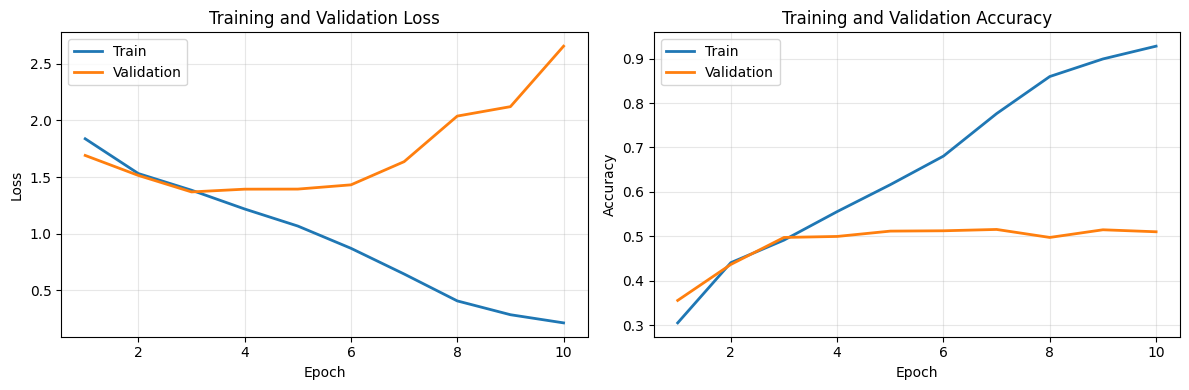

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)
# Plot training and validation loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot training and validation accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], label='Validation', linewidth=2)
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate the Best Model on the Test Set

In [17]:
# Load the best model checkpoint saved during validation
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} (val acc {checkpoint["val_acc"]:.4f})')

# Evaluate the best model on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest loss: {test_loss:.4f}')
print(f'Test accuracy (class-level): {test_acc:.4f}')

Loaded best model from epoch 7 (val acc 0.5154)

Test loss: 1.7145
Test accuracy (class-level): 0.5079


## 10. Analyze Accuracy Per Class

In [18]:
def collect_predictions(model, loader, device):
    # Set the model to evaluation mode
    model.eval()
    all_preds, all_labels = [], []

    # Collect predicted labels and true labels from the test set
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# Collect predicted labels and true labels from the test set
y_pred, y_true = collect_predictions(model, test_loader, device)
print('Accuracy per class')

# Calculate accuracy for each class separately
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        print(f'  {cls:<10s} {acc:.4f}  ({mask.sum()} samples)')

Accuracy per class
  bicycle    0.6667  (150 samples)
  bird       0.7200  (150 samples)
  car        0.6133  (150 samples)
  cat        0.3800  (150 samples)
  dog        0.1733  (150 samples)
  flower     0.5533  (150 samples)
  fruit      0.5533  (150 samples)
  shoe       0.4867  (150 samples)
  vegetable  0.4135  (133 samples)


## 11. Confusion Matrix and Classification Report

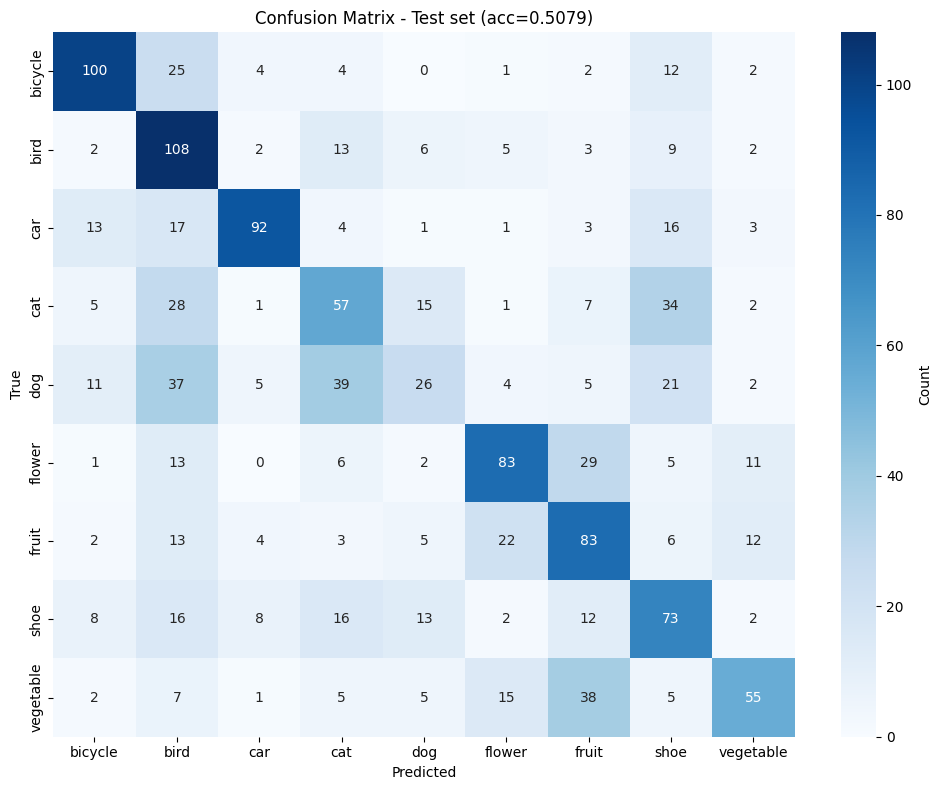


Classification report
              precision    recall  f1-score   support

     bicycle     0.6944    0.6667    0.6803       150
        bird     0.4091    0.7200    0.5217       150
         car     0.7863    0.6133    0.6891       150
         cat     0.3878    0.3800    0.3838       150
         dog     0.3562    0.1733    0.2332       150
      flower     0.6194    0.5533    0.5845       150
       fruit     0.4560    0.5533    0.5000       150
        shoe     0.4033    0.4867    0.4411       150
   vegetable     0.6044    0.4135    0.4911       133

    accuracy                         0.5079      1333
   macro avg     0.5241    0.5067    0.5028      1333
weighted avg     0.5231    0.5079    0.5029      1333



In [19]:
# Compute the confusion matrix using true and predicted labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

# Visualize how often each true class was predicted as each class
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Test set (acc={test_acc:.4f})')
plt.tight_layout()
plt.show()

# Print precision, recall, and F1-score for each class
print('\nClassification report')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

In [20]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>